In [1]:
import torch

In [2]:
model_path = '../models/rnn_seq2seq2.pt'

In [3]:
### Select device (GPU) ###

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'


print('Selected device:', device)

Selected device: cuda


In [4]:
import pandas as pd

### Reading data set ###

df = pd.read_csv('../data-sets/eng-nld.txt', sep='\t', header=None, usecols=[0, 1], names=['ENG', 'NLD'], dtype='string')
df.dropna()


print(df.info())
print()
print(df.sample())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76158 entries, 0 to 76157
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ENG     76158 non-null  string
 1   NLD     76158 non-null  string
dtypes: string(2)
memory usage: 1.2 MB
None

                   ENG                     NLD
7627  You cannot lose.  Je kan niet verliezen.


In [5]:
import numpy as np
from nltk import word_tokenize

### Preprocessing ###

train_frac = 0.8
max_size = 15

sos_token = "<sos>"
eos_token = "<eos>"


# Tokenize
df['eng_tokens'] = df['ENG'].apply(lambda x: [sos_token] + word_tokenize(x.lower()) + [eos_token])
df['nld_tokens'] = df['NLD'].apply(lambda x: [sos_token] + word_tokenize(x.lower()) + [eos_token])

# Trim
df = df.drop(df[
    (df['eng_tokens'].map(len) > max_size) | 
    (df['nld_tokens'].map(len) > max_size)
].index)

# Split
df = df.sample(frac=1).reset_index(drop=True)
split = int(train_frac * len(df))

train_data = df.iloc[:split, :]
test_data  = df.iloc[split:, :]
test_data.reset_index(drop=True, inplace=True)


print('Total rows from file:', len(df))
print('Total rows of train data::', len(train_data))
train_data

Total rows from file: 74209
Total rows of train data:: 59367


,ENG,NLD,eng_tokens,nld_tokens
0,Some people are afraid of ghosts.,Sommige mensen zijn bang van spoken.,"[<sos>, some, people, are, afraid, of, ghosts,...","[<sos>, sommige, mensen, zijn, bang, van, spok..."
1,That scared me.,Ik schrik daarvan.,"[<sos>, that, scared, me, ., <eos>]","[<sos>, ik, schrik, daarvan, ., <eos>]"
2,Perhaps we can do something about that.,Wij kunnen daar misschien wat aan doen.,"[<sos>, perhaps, we, can, do, something, about...","[<sos>, wij, kunnen, daar, misschien, wat, aan..."
3,I touched you.,Ik heb je aangeraakt.,"[<sos>, i, touched, you, ., <eos>]","[<sos>, ik, heb, je, aangeraakt, ., <eos>]"
4,I could have terminal cancer.,Misschien heb ik wel terminale kanker.,"[<sos>, i, could, have, terminal, cancer, ., <...","[<sos>, misschien, heb, ik, wel, terminale, ka..."
...,...,...,...,...
59362,What are you washing?,Wat ben je aan het wassen?,"[<sos>, what, are, you, washing, ?, <eos>]","[<sos>, wat, ben, je, aan, het, wassen, ?, <eos>]"
59363,Can I take a look around?,Mag ik even rondkijken?,"[<sos>, can, i, take, a, look, around, ?, <eos>]","[<sos>, mag, ik, even, rondkijken, ?, <eos>]"
59364,"Although it was raining, I had to go out.","Hoewel het regende, moest ik toch naar buiten ...","[<sos>, although, it, was, raining, ,, i, had,...","[<sos>, hoewel, het, regende, ,, moest, ik, to..."
59365,That restaurant's too expensive.,Dat restaurant is te duur.,"[<sos>, that, restaurant, 's, too, expensive, ...","[<sos>, dat, restaurant, is, te, duur, ., <eos>]"


In [6]:
import torchtext

min_freq  = 2
unk_token = '<unk>'
pad_token = '<pad>'

special_tokens = [unk_token, pad_token, sos_token, eos_token]


eng_vocab = torchtext.vocab.build_vocab_from_iterator(
    df['eng_tokens'],
    min_freq=min_freq,
    specials=special_tokens
)


nld_vocab = torchtext.vocab.build_vocab_from_iterator(
    df['nld_tokens'],
    min_freq=min_freq,
    specials=special_tokens
)

eng_vocab.set_default_index(eng_vocab[unk_token])
nld_vocab.set_default_index(nld_vocab[unk_token])


print('Unique tokens in \'eng_tokens\' column:', len(eng_vocab))
print('Unique tokens in \'nld_tokens\' column:', len(nld_vocab))

Unique tokens in 'eng_tokens' column: 6565
Unique tokens in 'nld_tokens' column: 8353


In [7]:
import random
import numpy as np

### Vectorize data set ###

eng_pad_index = eng_vocab[pad_token]
nld_pad_index = nld_vocab[pad_token]


def build_dataset(subset):
    X = np.zeros((len(subset), max_size), dtype=np.int32)
    Y = np.zeros((len(subset), max_size), dtype=np.int32)
        
    for ix, row in subset.iterrows():
        eng_ixs = eng_vocab.lookup_indices(row['eng_tokens'])
        eng_ixs = eng_ixs + [eng_pad_index] * (max_size - len(eng_ixs))

        nld_ixs = nld_vocab.lookup_indices(row['nld_tokens'])
        nld_ixs = nld_ixs + [nld_pad_index] * (max_size - len(nld_ixs))

        X[ix] = eng_ixs
        Y[ix] = nld_ixs

    X = torch.tensor(X, dtype=torch.long)
    Y = torch.tensor(Y, dtype=torch.long)

    return X, Y


Xtr, Ytr = build_dataset(train_data)
Xte, Yte = build_dataset(test_data)


print('Xtr shape:', Xtr.shape)
print()
ix = random.randint(0, len(Xtr))
print(Xtr[ix].tolist())
print(Ytr[ix].tolist())
print()
print(eng_vocab.lookup_tokens(Xtr[ix].tolist()))
print(nld_vocab.lookup_tokens(Ytr[ix].tolist()))


Xtr shape: torch.Size([59367, 15])

[2, 6, 94, 416, 34, 4, 3, 1, 1, 1, 1, 1, 1, 1, 1]
[2, 6, 21, 48, 87, 751, 4, 3, 1, 1, 1, 1, 1, 1, 1]

['<sos>', 'tom', 'never', 'called', 'mary', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
['<sos>', 'tom', 'heeft', 'mary', 'nooit', 'gebeld', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


In [8]:
import torch.nn as nn

### Bidirection Encoder ###

class Encoder(nn.Module):

    def __init__(self, vocab_size, emb_dim, hidden_size, n_layers=1, dropout=0):
        super(Encoder, self).__init__()

        self.n_layers    = n_layers

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.GRU(emb_dim, hidden_size, n_layers, batch_first=True, dropout=dropout, bidirectional=True)

        self.dropout    = nn.Dropout(dropout)
        

    def forward(self, input):
        # input = [batch size, sequence length]

        embeddings = self.dropout(self.embeddings(input))
        # embeddings = [batch size, sequence length, embedding dim]

        output, hidden = self.rnn(embeddings)
        # output = [batch size, sequence length, 2 * hidden size]
        # hidden = [2 * n layers, batch size, hidden size]

        return output, hidden

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class BahdanauAttention(nn.Module):

    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()

        self.w = nn.Linear(hidden_size*2, hidden_size)
        self.v = nn.Linear(hidden_size, 1)


    def forward(self, hidden, encodings):
        # hidden    = [n layers, batch size, hidden size * 2]
        # encodings = [batch size, input sequence length, hidden size * 2]

        hidden = hidden.permute(1, 0, 2)
        # hidden = [batch size, n layers, hidden size * 2]

        sequence_length = encodings.shape[1]
        hidden = hidden[:, -1, :].unsqueeze(1).repeat(1, sequence_length, 1)
        # hidden = [batch size, input sequence length, hidden size * 2]

        scores = self.v(torch.tanh(self.w(torch.add(hidden, encodings))))
        # scores = [batch size, input sequence length, 1]

        scores = scores.squeeze(2)
        # scores = [batch size, input sequence length]

        weights = F.softmax(scores, dim=-1)
        # weights = [batch size, input sequence length]

        weights = weights.unsqueeze(1)
        # weights = [batch size, 1, input sequence length]

        return  weights

In [10]:
import torch.nn as nn

class Decoder(nn.Module):
    
    def __init__(self, vocab_size, emb_dim, hidden_size, n_layers=1, dropout=0):
        super(Decoder, self).__init__()

        self.vocab_size = vocab_size

        self.w          = nn.Linear(hidden_size*2, hidden_size)
        self.attention  = BahdanauAttention(hidden_size)

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.GRU(emb_dim + hidden_size*2, hidden_size*2, n_layers, batch_first=True, dropout=dropout)
        
        self.fc         = nn.Linear(hidden_size*2, vocab_size)

        self.dropout    = nn.Dropout(dropout)


    def forward(self, input, hidden, encodings):
        # input     = [batch size]
        # hidden    = [n layers, batch size, hidden size * 2]
        # encodings = [batch size, input sequence length, hidden size * 2]

        input = input.unsqueeze(1)
        # input = [batch size, 1]

        embeddings = self.dropout(self.embeddings(input))
        # embeddings = [batch size, 1, embedding dim]

        att_weights = self.attention(hidden, encodings)
        # att_weights = [batch size, 1, input sequence length]

        weighted_vectors = torch.bmm(att_weights, encodings)
        # context = [batch size, 1, hidden size * 2]
        
        rnn_input = torch.cat((embeddings, weighted_vectors), dim=2)
        # rnn_input = [batch size, 1, embedding dim + hidden size * 2]

        output, hidden = self.rnn(rnn_input, hidden)
        # output = [batch size, 1, hidden size]
        # hidden = [n layers, batch size, hidden size]

        prediction = self.fc(output.squeeze(1))
        # prediction = [batch size, vocab size]

        return prediction, hidden

In [11]:
import re
import torch.nn as nn

class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
    
    
    def forward(self, source, target, teacher_force_ratio=0):
        # source = [batch size, sequence length]
        # target = [batch size, sequence length]

        batch_size        = target.shape[0]
        sequence_length   = target.shape[1]
        target_vocab_size = self.decoder.vocab_size


        #### 1. Encoding ###
        encodings, hidden = self.encoder(source)
        # encodings = [batch size, sequence length, 2 * hidden size]
        # hidden    = [2 * n layers, batch size, hidden size]


        ### 2. Decoding ###
        input = target[:, 0] # first input to the decoder is the <sos> tokens
        outputs = torch.zeros(sequence_length, batch_size, target_vocab_size).to(device)
        # input = [batch size]
        # outputs = [sequence length, batch size, vocab length]

        hidden = hidden.view(self.encoder.n_layers, 2, batch_size, hidden.shape[2])
        hidden = torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=2)
        # hidden = [n layers, batch size, 2 * hidden size]
        
        for i in range(1, sequence_length):
            output, hidden = self.decoder(input, hidden, encodings)
            # output = [batch size, sequence length, vocab size]

            outputs[i] = output
            
            if random.random() < teacher_force_ratio:
                input = target[:, i] # force teach
            else:
                input = torch.argmax(output, dim=1)
        
        outputs = outputs.permute(1, 2, 0)
        # outputs = [batch size, vocab size, sequence length]
        
        return outputs


    @torch.inference_mode()
    def translate(self, sentence, max_output_length=20):
        self.eval()
        
        nld_sos_index = nld_vocab[sos_token]
        nld_eos_index = nld_vocab[eos_token]

        tokens = [sos_token] + word_tokenize(sentence.lower()) + [eos_token]
        ixs = eng_vocab.lookup_indices(tokens)
        tensor = torch.tensor(ixs).unsqueeze(0).to(device)

        # Encode English sentence
        hidden, cell = self.encoder(tensor)

        hidden = hidden.view(self.encoder.n_layers, 2, 1, hidden.shape[2])
        hidden = torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=2)
        cell   = cell.view(self.encoder.n_layers, 2, 1, cell.shape[2])
        cell   = torch.cat((cell[:, 0, :, :], cell[:, 1, :, :]), dim=2)

        # Decode to Dutch
        indices = [nld_sos_index]
        for _ in range(max_output_length):
            inputs_tensor = torch.tensor(indices[-1]).unsqueeze(0).to(device)
            output, hidden, cell = self.decoder(inputs_tensor, hidden, cell)
            prediction = torch.argmax(output, dim=1).item()
            indices.append(prediction)
            if(prediction == nld_eos_index):
                break
        
        tokens = nld_vocab.lookup_tokens(indices)
        tokens = [t for t in tokens if t not in (eos_token, sos_token)]
        sentence = ' '.join(tokens).capitalize()
        sentence = re.sub(r'\s+([.,!?])', r'\1', sentence)

        return sentence

In [12]:
emb_dim     = 300
hidden_size = 512
n_layers    =   2
dropout     = 0.5

encoder = Encoder(len(eng_vocab), emb_dim, hidden_size, n_layers=n_layers, dropout=dropout)
decoder = Decoder(len(nld_vocab), emb_dim, hidden_size, n_layers=n_layers, dropout=dropout)
model   = Seq2Seq(encoder, decoder).to(device)

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 34829482


In [13]:
import os.path

# if os.path.isfile(model_path):
#     print('Found saved model on', model_path)
#     model.load_state_dict(torch.load(model_path))

In [14]:
lr = 0.0001


# Gradually lower forced teaching ratio throughout the training
def forced_teaching_ratio(current_epoch, total_epochs, initial_ratio=0.9, final_ratio=0):
    progress = current_epoch / total_epochs
    return initial_ratio - (initial_ratio - final_ratio) * progress

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [15]:
import torch.nn.functional as F

def log_statistics(parameters, eval_batch_size):
    gradients_norm = torch.tensor(
        [torch.norm(param.grad).item() for param in parameters if param.grad is not None]
    ).norm().item()
    
    inputs = torch.zeros((eval_batch_size, max_size), dtype=torch.long).to(device)
    inputs[:, 0] = nld_vocab[sos_token]

    model.eval()
    with torch.inference_mode():
    
        # Sample larger train-batch
        ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,))
        Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)
        
        outputs = model(Xb, inputs)
        loss = F.cross_entropy(outputs, Yb)

        # Sample larger test-batch
        ix = torch.randint(0, Xte.shape[0], (eval_batch_size,))
        Xb, Yb = Xte[ix].to(device), Yte[ix].to(device)

        outputs = model(Xb, inputs)
        test_loss = F.cross_entropy(outputs, Yb)
        
        return loss.item(), test_loss.item(), gradients_norm

In [16]:
from tqdm import trange

### Train network ###

epochs              = 100000
batch_size          =     64
eval_batch_size     =   6400

epoch_count       = []
ratio_values      = []
train_loss_values = []
test_loss_values  = []
gradients_norm    = []


for epoch in trange(epochs):
    model.train()


    ratio = forced_teaching_ratio(epoch, epochs)

    # Sample mini-batch and send to gpu
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)

    output = model(Xb, Yb, ratio) # Do the forward pass
    loss = criterion(output, Yb)  # Calculate the loss
    optimizer.zero_grad()         # Reset parameters
    loss.backward()               # Backpropagation
    optimizer.step()              # Update parameters

    # Report progression every so often
    if ((epoch + 1) % (epochs / 50) == 0):
        train_loss, test_loss, grad_norm = log_statistics(model.parameters(), eval_batch_size)

        epoch_count.append(epoch)
        train_loss_values.append(train_loss)
        test_loss_values.append(test_loss)
        gradients_norm.append(grad_norm)
        ratio_values.append(ratio)


# Print final results
print()
print('Final training loss:', round(loss.item(), 3))
print('Final test loss:    ', round(test_loss.item(), 3))

 21%|██        | 20931/100000 [23:50<1:30:04, 14.63it/s]


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), model_path)

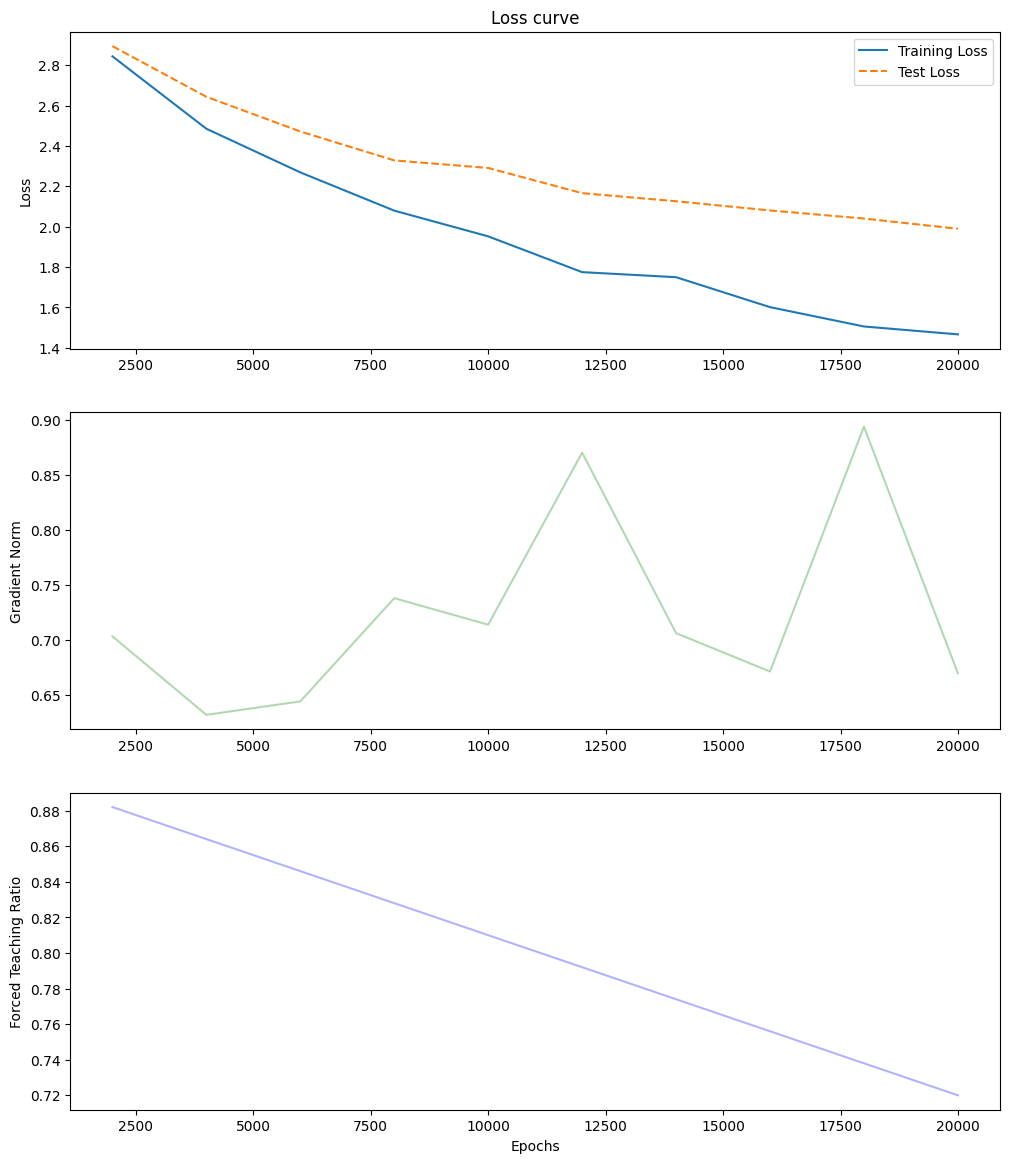

In [17]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14))

# Plot training and test loss on the first subplot
ax1.plot(epoch_count, train_loss_values, label='Training Loss')
ax1.plot(epoch_count, test_loss_values, label='Test Loss', linestyle='--')
ax3.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Loss curve')
ax1.legend(loc='upper right')

# Plot gradient norm on the second subplot
ax2.plot(epoch_count, gradients_norm, 'g', alpha=0.3)
ax3.set_xlabel('Epochs')
ax2.set_ylabel('Gradient Norm')

# Plot forced teaching ratio decay on the third subplot
ax3.plot(epoch_count, ratio_values, 'b', alpha=0.3)
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Forced Teaching Ratio')

plt.show()

In [ ]:
### Use model ###

print(model.translate('I\'m very happy.'))
print(model.translate('He\'s very sad.'))
print(model.translate('That man is wearing a white shirt.'))
print(model.translate('He\'s afraid of spiders.'))
print(model.translate('He\'s going home to his wife.'))
print(model.translate('Those guys are walking to work.'))
print(model.translate('I\'m not going with you today.'))
print(model.translate('My girlfriend will not come over tomorrow.'))